# Дипломный проект. Яндекс.Афиша

## Введение

**Описание проекта**

В этом проекте вы будете работать с данными сервиса Яндекс Афиша. С его помощью пользователи могут узнавать информацию о мероприятиях в разных городах и покупать на них билеты. Сервис сотрудничает с партнёрами — организаторами мероприятий и билетными операторами, которые предоставляют информацию о событиях и выставляют билеты на продажу.

Представьте, что на дворе ноябрь 2024 года. Пора готовиться к зимним праздникам, однако сотрудники из отдела продукта увидели кое-что важное: продажи билетов на одни мероприятия неожиданно растут, а на другие — снижаются.

В чём причина, пока не ясно. Может, сработал фактор сезонности, и пользователи поменяли предпочтения? Или изменилась аудитория? Стоит также разобраться, какие события стали привлекать больше зрителей, а какие организаторы и площадки выбились в лидеры. А также понять, отличаются ли своей активностью пользователи мобильных устройств от клиентов, которые бронируют билеты со стационарного компьютера.

Пока у команды есть только догадки и нет ответов. Тем временем близится период распродаж и новогодних акций, и сервис должен основательно к нему подготовиться. Чтобы принимать взвешенные решения, нужна детальная аналитика и убедительные инсайты.

**Цель проекта**

Провести исследовательский анализ данных в Python. Это поможет сделать выводы об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверить гипотезу о разнице в поведении пользователей с мобильных и стационарных устройств. Такой анализ дополнит данные дашборда и поможет команде продукта получить инсайты об изменении пользовательских предпочтений.

**Содержание проекта**

- **Шаг 0.** Оформление тетрадки Jupyter Notebook
- **Шаг 1.** Загрузка данных и знакомство с ними
- **Шаг 2.** Предобработка данных и подготовка их к исследованию
- **Шаг 3.** Исследовательский анализ данных
  - **3.1.** Анализ распределения заказов по сегментам и их сезонные изменения
  - **3.2.** Осенняя активность пользователей
  - **3.3.** Популярные события и партнёры
- **Шаг 4.** Статистический анализ данных
- **Шаг 5.** Общий вывод и рекомендации


**Описание данных**

Первый датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. Поля датасета соответствуют таблице `purchases`, с которой вы работали в предыдущих заданиях:
- `order_id` — уникальный идентификатор заказа.
- `user_id` — уникальный идентификатор пользователя.
- `created_dt_msk` — дата создания заказа (московское время).
- `created_ts_msk` — дата и время создания заказа (московское время).
- `event_id` — идентификатор мероприятия из таблицы events.
- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- `age_limit` — возрастное ограничение мероприятия.
- `currency_code` — валюта оплаты, например rub для российских рублей.
- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- `revenue` — выручка от заказа.
- `service_name` — название билетного оператора.
- `tickets_count` — количество купленных билетов.
- `total` — общая сумма заказа.

В данные также был добавлен столбец `days_since_prev` с количеством дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.

Второй датасет `final_tickets_events_df` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Обратите внимание, что из данных исключили фильмы, ведь, как было видно на дашборде, событий такого типа не так много. Датасет содержит такие поля:
- `event_id` — уникальный идентификатор мероприятия.
- `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- `event_type_description` — описание типа мероприятия.
- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.
- `organizers` — организаторы мероприятия.
- `region_name` — название региона.
- `city_name` — название города.
- `venue_id` — уникальный идентификатор площадки.
- `venue_name` — название площадки.
- `venue_address` — адрес площадки.

Анализ данных в предыдущей части проекта показал, что выручка от заказов представлена в двух валютах — российских рублях и казахстанских тенге. Для удобства решения было бы корректно привести данные к одной валюте, например к российским рублям. Для этого в вашем распоряжении будет датасет `final_tickets_tenge_df.csv` с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. Датасет содержит такие поля:
- `nominal` — номинал (100 тенге).
- `data` — дата.
- `curs` — курс тенге к рублю.
- `cdx` — обозначение валюты (kzt).

## Шаг 1. Загрузка данных и знакомство с ними

Загрузим необходимые библиотеки:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu

Загрузим данные из датасетов:

In [2]:
orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')
events = pd.read_csv('/datasets/final_tickets_events_df.csv')
tenge_rate = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

Объединим данные для дальнейшей предобработки

In [3]:
df = orders.merge(events, on = 'event_id')

Выведем информацию, которая необходима для принятия решений о предобработке:

In [4]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290611 non-null  int64  
 1   user_id                 290611 non-null  object 
 2   created_dt_msk          290611 non-null  object 
 3   created_ts_msk          290611 non-null  object 
 4   event_id                290611 non-null  int64  
 5   cinema_circuit          290611 non-null  object 
 6   age_limit               290611 non-null  int64  
 7   currency_code           290611 non-null  object 
 8   device_type_canonical   290611 non-null  object 
 9   revenue                 290611 non-null  float64
 10  service_name            290611 non-null  object 
 11  tickets_count           290611 non-null  int64  
 12  total                   290611 non-null  float64
 13  days_since_prev         268698 non-null  float64
 14  event_name          

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"


**Вывод по итогам первичного знакомства с данными:**

В результате загрузки и первичного анализа данных получены следующие наблюдения:

1. **Общая структура:** объединенный датафрейм `df` содержит 290 611 записей и 24 столбца. Данные представляют собой информацию о заказах билетов, мероприятиях, пользователях и билетных операторах.

2. **Типы данных:**
   - Столбцы с датой и временем (`created_dt_msk`, `created_ts_msk`) имеют тип `object`, что требует преобразования в `datetime64[ns]` для корректной временной аналитики.
   - Остальные столбцы имеют корректные типы: числовые (`int64`, `float64`) для идентификаторов, выручки, количества билетов; категориальные (`object`) для наименований, типов мероприятий, регионов и т.д.

3. **Пропуски:**
   - Единственный столбец с явными пропусками — `days_since_prev` (21 913 пропусков, около 7,5% от общего объема). Это соответствует описанию данных: для первых покупок пользователей значение отсутствует, что является нормой.
   - Остальные столбцы не содержат пропусков, что свидетельствует о хорошем качестве выгрузки и целостности данных при объединении.

4. **Качество данных:**
   - Требуется дополнительная проверка на скрытые пропуски (например, значения `'нет'`, `''`, `'nan'` в категориальных столбцах) и выбросы в числовых показателях (`revenue`, `tickets_count`).

5. **Необходимые преобразования:**
   - Преобразование `created_dt_msk` и `created_ts_msk` в datetime.
   - Приведение валют к единому стандарту (рубли) с использованием данных о курсе тенге.
   - Обработка выбросов по 99-му процентилю для `revenue` и `tickets_count`.
   - Проверка категориальных столбцов на скрытые пропуски.
   - Создание новых признаков: `revenue_rub`, `one_ticket_revenue_rub`, `month`, `season`.

## Шаг 2. Предобработка данных и подготовка их к исследованию

Изменим тип данных в столбцах `created_dt_msk` и `created_ts_msk` на корректный:

In [5]:
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])
print(df['created_dt_msk'].dtype)
print(df['created_ts_msk'].dtype)

datetime64[ns]
datetime64[ns]


Проверим данные на пропуски:

In [6]:
print('Абсолютное количество пропусков:')
print(df.isna().sum().sort_values(ascending = False))

Абсолютное количество пропусков:
days_since_prev           21913
order_id                      0
user_id                       0
venue_name                    0
venue_id                      0
city_id                       0
city_name                     0
region_name                   0
organizers                    0
event_type_main               0
event_type_description        0
event_name                    0
total                         0
tickets_count                 0
service_name                  0
revenue                       0
device_type_canonical         0
currency_code                 0
age_limit                     0
cinema_circuit                0
event_id                      0
created_ts_msk                0
created_dt_msk                0
venue_address                 0
dtype: int64


Как и предполагалось, явные пропуски содержаться только в столбце `days_since_prev`

Проверим данные на скрытые пропуски:

In [7]:
#Выделим столбцы с типом данных object:
key_categorical = ['user_id', 'cinema_circuit', 'currency_code', 'device_type_canonical', 'service_name', 'event_name', 'event_type_description', 'event_type_main', 'organizers', 'region_name', 'city_name', 'venue_name', 'venue_address']

#Напишем цикл для проверки на пропуски:
for col in key_categorical:
    print(f"\n{col}:")
    if '' in df[col].values or 'nan' in df[col].values or 'нет' in df[col].values or 'неизвестно' in df[col].values:
        print(f"  Есть скрытые пропуски ('', 'nan', 'нет', 'неизвестно')")
    else: 
        print('Скрытых пропусков нет')


user_id:
Скрытых пропусков нет

cinema_circuit:
  Есть скрытые пропуски ('', 'nan', 'нет', 'неизвестно')

currency_code:
Скрытых пропусков нет

device_type_canonical:
Скрытых пропусков нет

service_name:
Скрытых пропусков нет

event_name:
Скрытых пропусков нет

event_type_description:
Скрытых пропусков нет

event_type_main:
Скрытых пропусков нет

organizers:
Скрытых пропусков нет

region_name:
Скрытых пропусков нет

city_name:
Скрытых пропусков нет

venue_name:
Скрытых пропусков нет

venue_address:
Скрытых пропусков нет


Проверим данные на "чистоту":

In [8]:
for column in ['age_limit', 'currency_code', 'device_type_canonical', 'service_name']:
    print(f"\nColumn: {column}")
    print("Unique values:", df[column].unique())
    print("Missing values count:", df[column].isna().sum())
    print("Value counts:")
    print(df[column].value_counts(dropna=False), "\n")


Column: age_limit
Unique values: [16  0 18 12  6]
Missing values count: 0
Value counts:
16    78556
12    62474
0     61487
6     52161
18    35933
Name: age_limit, dtype: int64 


Column: currency_code
Unique values: ['rub' 'kzt']
Missing values count: 0
Value counts:
rub    285542
kzt      5069
Name: currency_code, dtype: int64 


Column: device_type_canonical
Unique values: ['mobile' 'desktop']
Missing values count: 0
Value counts:
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64 


Column: service_name
Unique values: ['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Билеты в руки' 'Облачко' 'Дом культуры'
 'Весь в билетах' 'Лучшие билеты' 'Прачечная' 'Выступления.ру' 'Мир касс'
 'Тебе билет!' 'Быстробилет' 'Яблоко' 'Show_ticket'
 'Городской дом культуры' 'Билет по телефону' 'Crazy ticket!' 'Росбилет'
 'Шоу начинается!' 'Цвет и билет' 'Быстрый кассир' 'Восьмёрка' 'Телебилет'
 'Реестр' 'КарандашРУ' 'Радио ticket' 'Дырокол' 'В

В целом данные распределены нормально, нет каких-то аномальных значений или значений, которые не предполагались в данных. Есть 3 билетных оператора с малым количеством заказов билетов, но их процент ничтожно мал и не повлияет на результаты исследования.

Скрытые пропуски были обнаружены в столбце `cinema_circuit`, но, т.к. в этом столбце значение "нет" является нормой, то не учитываем данный столбец.

Посмотрим на расспределение и наличие выбросов в столбцах с количественными значениями:

In [9]:
#Отфильтруем значения для рублей:
df_rub = df[df['currency_code'] == 'rub']
df_rub['revenue'].describe()

count    285542.000000
mean        548.013929
std         871.750181
min         -90.760000
25%         114.170000
50%         346.630000
75%         793.320000
max       81174.540000
Name: revenue, dtype: float64

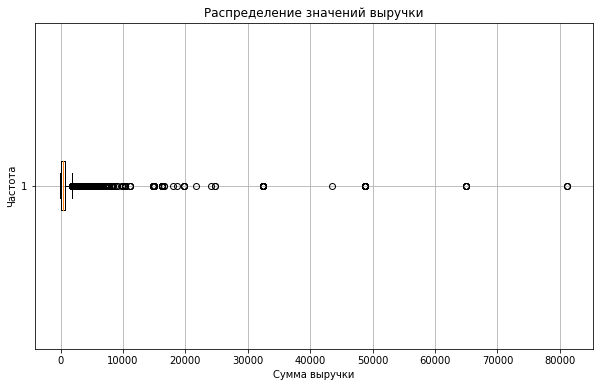

In [10]:
plt.figure(figsize=(10, 6))
plt.boxplot(df_rub['revenue'],
            vert = False)
plt.title('Распределение значений выручки')
plt.xlabel('Сумма выручки')
plt.ylabel('Частота')
plt.grid()
plt.show()

Отфильтруем данные по 99 процентилю:

In [11]:
outliers = df_rub['revenue'].quantile(0.99)
df_rub_new = df_rub.loc[df_rub['revenue'] < outliers]
df_rub_new['revenue'].describe()

count    282685.000000
mean        510.393032
std         500.127831
min         -90.760000
25%         112.090000
50%         340.600000
75%         781.720000
max        2569.610000
Name: revenue, dtype: float64

Повторим эти действия для данных в тенге:

In [12]:
df_kzt = df[df['currency_code'] == 'kzt']
df_kzt['revenue'].describe()

count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64

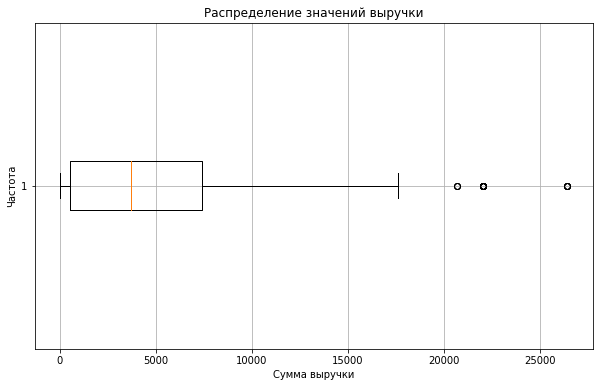

In [13]:
plt.figure(figsize=(10, 6))
plt.boxplot(df_kzt['revenue'],
            vert = False)
plt.title('Распределение значений выручки')
plt.xlabel('Сумма выручки')
plt.ylabel('Частота')
plt.grid()
plt.show()

Так же как и с рублевыми данными, отфильтруем данные по 99 процентилю:

In [14]:
outliers = df_kzt['revenue'].quantile(0.99)
df_kzt_new = df_kzt.loc[df_kzt['revenue'] < outliers]
df_kzt_new['revenue'].describe()

count     4844.000000
mean      4378.842494
std       4072.645224
min          0.000000
25%        486.030000
50%       3698.830000
75%       7076.240000
max      17230.320000
Name: revenue, dtype: float64

Объединим полученные данные в одни датафрейм:

In [15]:
df_cleaned = pd.concat([df_rub_new, df_kzt_new], ignore_index=True)

Теперь повторим эти действия с даннымии о количестве билетов:

In [16]:
df_cleaned['tickets_count'].describe()

count    287529.000000
mean          2.739108
std           1.162387
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

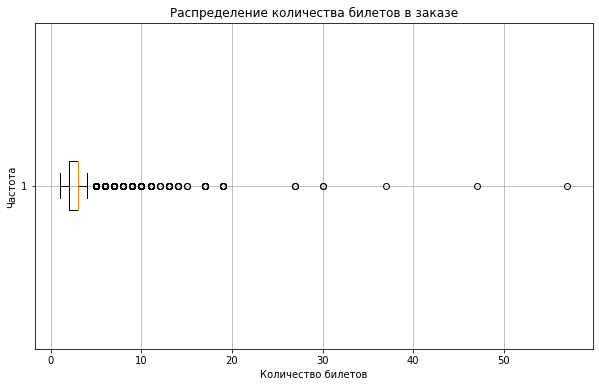

In [17]:
plt.figure(figsize=(10, 6))
plt.boxplot(df_cleaned['tickets_count'], 
            vert=False)
plt.title('Распределение количества билетов в заказе')
plt.xlabel('Количество билетов')
plt.ylabel('Частота')
plt.grid()
plt.show()

Фильтруем по 99 процентилю:

In [18]:
outliers = df_cleaned['tickets_count'].quantile(0.99)
df_new= df_cleaned.loc[df_cleaned['tickets_count'] < outliers]
df_new['tickets_count'].describe()

count    283444.000000
mean          2.689254
std           1.076140
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max           5.000000
Name: tickets_count, dtype: float64

Проверим данные на дубликаты:

In [19]:
df_new.duplicated().sum()

0

Теперь проверим данные на скрытые дубликаты:

In [20]:
check_columns = ['user_id', 'event_id', 'created_ts_msk', 'tickets_count', 'revenue']
perfect_duplicates = df_new.groupby(check_columns).size().reset_index(name='count')
perfect_duplicates = perfect_duplicates[perfect_duplicates['count'] > 1]

print(f"Найдено групп дубликатов: {len(perfect_duplicates)}")

if len(perfect_duplicates) > 0:
    total_duplicate_rows = perfect_duplicates['count'].sum()
    print(f"Всего строк-дубликатов: {total_duplicate_rows}")
    print(f"Доля дубликатов: {total_duplicate_rows/len(df_new)*100:.4f}%")

Найдено групп дубликатов: 39
Всего строк-дубликатов: 81
Доля дубликатов: 0.0286%


В ходе проверки мы видим 81 строку с неявными дубликатами, где совпадают значения столбцов `user_id`, `event_id`, `created_ts_msk`, `tickets_count` и  `revenue`. Т.к. доля таких дубликатов составляет 0.0286%, то можно просто удалить дубликаты, оставив только первое вхождение.

In [21]:
df = df_new.drop_duplicates(subset=check_columns, keep='first')

Приведем выручку с заказа к единой валюте:

In [22]:
tenge_rate.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [23]:
tenge_rate['data'] = pd.to_datetime(tenge_rate['data'])
#Рассчитаем курс 1 тенге к рублю:
tenge_rate['rate_to_rub'] = tenge_rate['curs']/100
#Оставим только интересующие нас столбцы с датой и курсом:
tenge_rate_new = tenge_rate[['data', 'rate_to_rub']]
tenge_rate_new.head()

,data,rate_to_rub
0,2024-01-10,0.199391
1,2024-01-11,0.197255
2,2024-01-12,0.195839
3,2024-01-13,0.194501
4,2024-01-14,0.194501


Присоединим таблицу с курсом к нашему текущему датафрейму:

In [24]:
df_with_rate = df.merge(tenge_rate_new,
                        left_on='created_dt_msk', 
                        right_on='data', 
                        how='left')

In [25]:
df_with_rate['revenue_rub'] = df_with_rate['revenue'].where(
    #Оставим данные с рублями нетронутыми:
    df_with_rate['currency_code'] == 'rub',
    #Данные в тенге сконвертируем:
    df_with_rate['revenue'] * df_with_rate['rate_to_rub']
)

Рассчитаем выручку с продажи одного билета на мероприятие:

In [26]:
df_with_rate['one_ticket_revenue_rub'] = df_with_rate['revenue_rub']/df['tickets_count']

Выделим месяц оформления заказа в отдельный столбец:

In [27]:
df_with_rate['month'] = df_with_rate['created_dt_msk'].dt.month

Создадим столбец с информацией о сезонности:

In [28]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'

df_with_rate['season'] = df_with_rate['month'].apply(get_season)

Для дальнейшего удобства переименуем датафрейм:

In [29]:
df = df_with_rate

Выведем информацию о получившемся после обработки датафрейме:

In [30]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 283402 entries, 0 to 283401
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                283402 non-null  int64         
 1   user_id                 283402 non-null  object        
 2   created_dt_msk          283402 non-null  datetime64[ns]
 3   created_ts_msk          283402 non-null  datetime64[ns]
 4   event_id                283402 non-null  int64         
 5   cinema_circuit          283402 non-null  object        
 6   age_limit               283402 non-null  int64         
 7   currency_code           283402 non-null  object        
 8   device_type_canonical   283402 non-null  object        
 9   revenue                 283402 non-null  float64       
 10  service_name            283402 non-null  object        
 11  tickets_count           283402 non-null  int64         
 12  total                   283402

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_id,venue_id,venue_name,venue_address,data,rate_to_rub,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,0.186972,1521.94,380.485000,8,лето
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1902.42,380.484000,7,лето
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1141.45,380.483333,7,лето
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1902.42,380.484000,7,лето
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,0.183419,1521.94,380.485000,7,лето


**Промежуточный вывод по шагам 1-2**

**Шаг 1. Загрузка данных и знакомство с ними**

В ходе выполнения первого этапа были загружены три датасета:
- `final_tickets_orders_df.csv` — информация о заказах билетов (290 611 записей, 14 столбцов);
- `final_tickets_events_df.csv` — информация о мероприятиях (данные о событиях, исключая фильмы);
- `final_tickets_tenge_df.csv` — курс казахстанского тенге к российскому рублю за 2024 год.

Для дальнейшей работы данные были объединены по ключу `event_id` с использованием **INNER JOIN**, что позволило сохранить только заказы, по которым имеется полная информация о мероприятиях. В результате объединения получен датафрейм `df`, содержащий 290 611 записей и 24 столбца.

**Шаг 2. Предобработка данных и подготовка их к исследованию**

**2.1. Преобразование типов данных**
Столбцы с датой и временем (`created_dt_msk`, `created_ts_msk`) преобразованы в тип `datetime64[ns]`, что обеспечило корректную работу с временными рядами.

**2.2. Проверка пропусков**
- Явные пропуски (NaN) обнаружены только в столбце `days_since_prev` (21 913 пропусков), что соответствует описанию данных — для первых покупок пользователей значение отсутствует.
- Проведена проверка скрытых пропусков в категориальных столбцах. Значение `'нет'` в столбце `cinema_circuit` является корректной категорией, обозначающей отсутствие принадлежности к киносети. Иных скрытых пропусков не выявлено.

**2.3. Анализ количественных данных и обработка выбросов**
Анализ распределения выручки (`revenue`) проведен отдельно для рублей и тенге:
- Для заказов в рублях выручка варьируется от -90,76 до 81 174,54 руб. После фильтрации по 99-му процентилю (значение 2 569,61 руб.) в данных осталось 282 685 записей.
- Для заказов в тенге выручка варьируется от 0 до 26 425,86 тенге. После фильтрации по 99-му процентилю (значение 17 230,32 тенге) в данных осталось 4 844 записи.

Анализ количества билетов в заказе (`tickets_count`) показал, что основная масса заказов содержит от 1 до 3 билетов. После отсечения по 99-му процентилю (значение 5 билетов) количество заказов составило 283 444.

**2.4. Проверка дубликатов**
- Явные дубликаты (полное совпадение всех столбцов) отсутствуют.
- При проверке неявных дубликатов по комбинации столбцов `['user_id', 'event_id', 'created_ts_msk', 'tickets_count', 'revenue']` обнаружено 39 групп дубликатов, содержащих 81 строку (0,0286% от общего объема). Принято решение удалить дубликаты, оставив только первое вхождение.

**2.5. Приведение валют и создание новых признаков**
- На основе датасета с курсом тенге создан вспомогательный столбец `rate_to_rub = curs / 100`.
- После объединения с данными о заказах рассчитана выручка в рублях (`revenue_rub`) по формуле: если валюта — рубли, значение остается без изменений; если тенге — умножается на курс.
- Рассчитана выручка с продажи одного билета (`one_ticket_revenue_rub = revenue_rub / tickets_count`).
- Из столбца `created_dt_msk` выделен месяц оформления заказа (`month`).
- На основе месяца создан столбец `season` с категориями: 'зима', 'весна', 'лето', 'осень'.

**2.6. Итоговая структура данных**
После всех преобразований получен датафрейм `df`, содержащий **283 402** записи и **30** столбцов. Данные готовы к проведению исследовательского анализа.

## Шаг 3. Исследовательский анализ данных

###  3.1. Анализ распределения заказов по сегментам и их сезонные изменения

Для каждого месяца найдем количество заказов:

In [31]:
month_orders = df.groupby('month')['order_id'].count()
month_orders

month
6     33585
7     39860
8     43894
9     68341
10    97722
Name: order_id, dtype: int64

Визуализируем полученные данные:

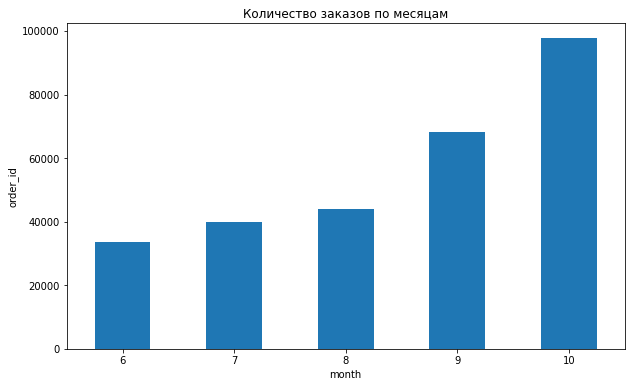

In [32]:
month_orders.plot(kind = 'bar',
                  title = 'Количество заказов по месяцам',
                  legend = False,
                  ylabel = 'order_id',
                  xlabel = 'month',
                  rot = 0,
                  figsize = (10, 6))
plt.show()

Для осеннего и летнего периодов сравним распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу:

Сравним распределение для разных типов мероприятий:

In [33]:
event_type_orders = df.groupby(['season', 'event_type_main'])['order_id'].count().reset_index()
#Пропишем общую сумму заказов для каждой группы в каждой строке для дальнейшейго рассчета доли каждого типа мероприятия:
event_type_orders['total_by_season'] = event_type_orders.groupby('season')['order_id'].transform('sum')
event_type_orders['share'] = (event_type_orders['order_id'] / event_type_orders['total_by_season'])
event_type_orders

,season,event_type_main,order_id,total_by_season,share
0,лето,выставки,2401,117339,0.020462
1,лето,другое,31712,117339,0.270260
2,лето,концерты,50150,117339,0.427394
3,лето,спорт,2923,117339,0.024911
4,лето,стендап,6221,117339,0.053017
5,лето,театр,23664,117339,0.201672
6,лето,ёлки,268,117339,0.002284
7,осень,выставки,2423,166063,0.014591
8,осень,другое,32563,166063,0.196088
9,осень,концерты,62132,166063,0.374147


Сравним распределение для разных типов устройств:

In [34]:
device_type_orders = df.groupby(['season', 'device_type_canonical'])['order_id'].count().reset_index()
device_type_orders['total_by_season'] = device_type_orders.groupby('season')['order_id'].transform('sum')
device_type_orders['share'] = (device_type_orders['order_id'] / device_type_orders['total_by_season'])
device_type_orders

,season,device_type_canonical,order_id,total_by_season,share
0,лето,desktop,22648,117339,0.193013
1,лето,mobile,94691,117339,0.806987
2,осень,desktop,33635,166063,0.202544
3,осень,mobile,132428,166063,0.797456


Сравним распределение для разных возрастных категорий:

In [35]:
age_limit_orders = df.groupby(['season', 'age_limit'])['order_id'].count().reset_index()
age_limit_orders['total_by_season'] = age_limit_orders.groupby('season')['order_id'].transform('sum')
age_limit_orders['share'] = (age_limit_orders['order_id'] / age_limit_orders['total_by_season'])
age_limit_orders

,season,age_limit,order_id,total_by_season,share
0,лето,0,20870,117339,0.177861
1,лето,6,21405,117339,0.182420
2,лето,12,24020,117339,0.204706
3,лето,16,33548,117339,0.285907
4,лето,18,17496,117339,0.149106
5,осень,0,38873,166063,0.234086
6,осень,6,29233,166063,0.176036
7,осень,12,36748,166063,0.221290
8,осень,16,43940,166063,0.264598
9,осень,18,17269,166063,0.103991


Визуализируем полученные данные:

Для типа мероприятия:

In [36]:
# Создадим сводную таблицу: строки = типы мероприятий, столбцы = сезоны, значения = доли
pivot_event = event_type_orders.pivot(index='event_type_main', columns='season', values='share')
print(pivot_event)

season               лето     осень
event_type_main                    
выставки         0.020462  0.014591
другое           0.270260  0.196088
концерты         0.427394  0.374147
спорт            0.024911  0.110675
стендап          0.053017  0.040918
театр            0.201672  0.253759
ёлки             0.002284  0.009822


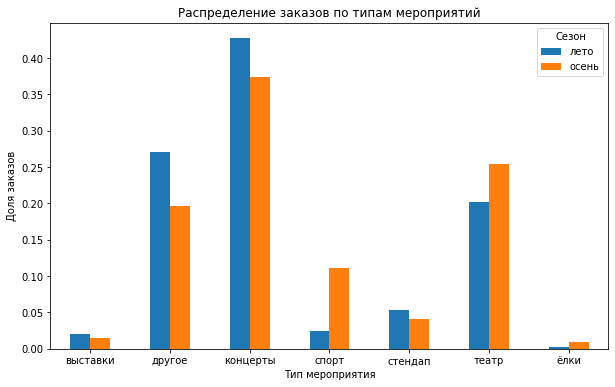

In [37]:
pivot_event.plot(kind= 'bar',
                 title= 'Распределение заказов по типам мероприятий',
                 ylabel= 'Доля заказов',
                 xlabel= 'Тип мероприятия',
                 rot= 0,
                 figsize= (10, 6))

plt.legend(title= 'Сезон')
plt.show()

Для типа устройства:

In [38]:
pivot_device = device_type_orders.pivot(index='device_type_canonical', columns='season', values='share')
print(pivot_device)

season                     лето     осень
device_type_canonical                    
desktop                0.193013  0.202544
mobile                 0.806987  0.797456


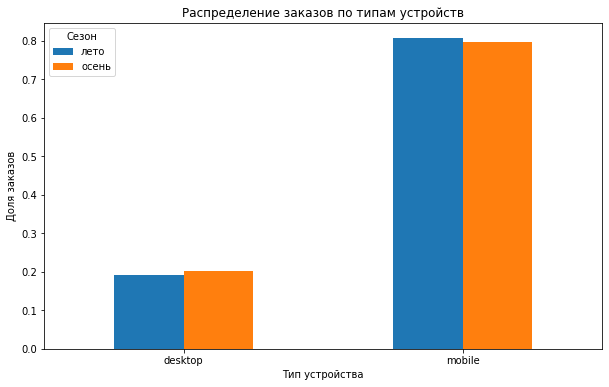

In [39]:
pivot_device.plot(kind= 'bar',
                  title= 'Распределение заказов по типам устройств',
                  ylabel= 'Доля заказов',
                  xlabel= 'Тип устройства',
                  rot= 0,
                  figsize= (10, 6))

plt.legend(title= 'Сезон')
plt.show()

Для возрастных категорий:

In [40]:
pivot_age = age_limit_orders.pivot(index='age_limit', columns='season', values='share')
print(pivot_age)

season         лето     осень
age_limit                    
0          0.177861  0.234086
6          0.182420  0.176036
12         0.204706  0.221290
16         0.285907  0.264598
18         0.149106  0.103991


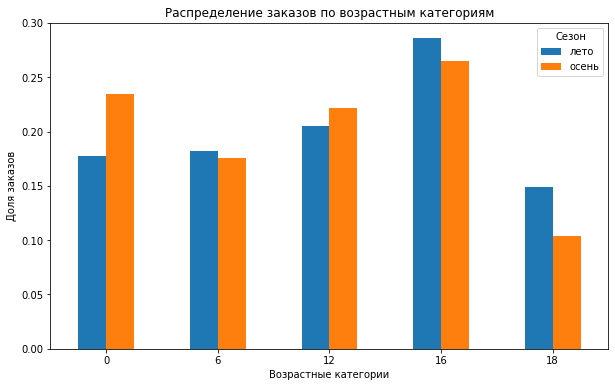

In [41]:
pivot_age.plot(kind= 'bar',
               title= 'Распределение заказов по возрастным категориям',
               ylabel= 'Доля заказов',
               xlabel= 'Возрастные категории',
               rot= 0,
               figsize= (10, 6))

plt.legend(title= 'Сезон')
plt.show()

Изучим изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью:

In [42]:
one_ticket = df.groupby(['season', 'event_type_main']).agg({
                                                            'tickets_count': 'sum',
                                                            'revenue': 'sum'}).reset_index()
one_ticket['one_ticket_revenue'] = one_ticket['revenue']/one_ticket['tickets_count']
one_ticket = one_ticket[['season', 'event_type_main', 'one_ticket_revenue']]
one_ticket

,season,event_type_main,one_ticket_revenue
0,лето,выставки,89.385917
1,лето,другое,86.479128
2,лето,концерты,410.234842
3,лето,спорт,55.661755
4,лето,стендап,217.199867
5,лето,театр,212.833402
6,лето,ёлки,267.878933
7,осень,выставки,92.509901
8,осень,другое,85.458752
9,осень,концерты,279.669462


In [43]:
#Создадим сводную таблицу для удобного рассчета разницы:
pivot_ticket = one_ticket.pivot(index='event_type_main', columns='season', values='one_ticket_revenue')
pivot_ticket['change'] = (pivot_ticket['осень'] - pivot_ticket['лето']) / pivot_ticket['лето']*100
print(pivot_ticket)

season                 лето       осень     change
event_type_main                                   
выставки          89.385917   92.509901   3.494939
другое            86.479128   85.458752  -1.179910
концерты         410.234842  279.669462 -31.826985
спорт             55.661755   53.973463  -3.033128
стендап          217.199867  229.991502   5.889338
театр            212.833402  177.546361 -16.579654
ёлки             267.878933  222.648427 -16.884682


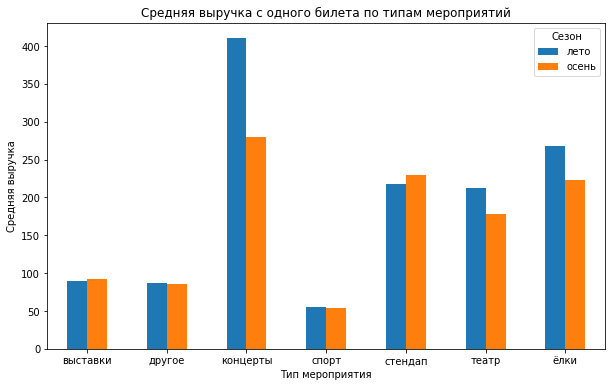

In [44]:
pivot_ticket[['лето', 'осень']].plot(kind= 'bar',
                                     title= 'Средняя выручка с одного билета по типам мероприятий',
                                     ylabel= 'Средняя выручка',
                                     xlabel= 'Тип мероприятия',
                                     rot= 0,
                                     figsize= (10, 6))

plt.legend(title='Сезон')
plt.show()

Визуализируем разницу между выручкой:

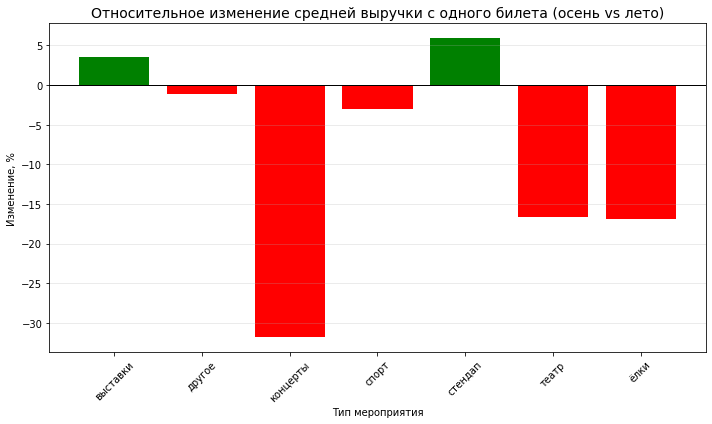

In [45]:
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in pivot_ticket['change']]
plt.bar(pivot_ticket.index, pivot_ticket['change'], color=colors)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.title('Относительное изменение средней выручки с одного билета (осень vs лето)', fontsize=14)
plt.xlabel('Тип мероприятия')
plt.ylabel('Изменение, %')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод:**

1. **Количество заказов по месяцам**

Как мы можем видеть исходя из расчётов, количество заказов с каждым месяцем увеличивается. Пик заказов приходится на осенние месяцы. В сентябре количество заказов составило - 68341, в октябре же количество возросло до 97722. Самый высокий показатель по количеству заказов летом составлял 43894, данное количество пришлось на Август.

2. **Распределение заказов по разным категориям**
   
- **Типы мероприятий**
   
   Летом люди больше покупали билеты на такие мероприятия: выставки, концерты, стендап и другое. Осенью же люди больше   предпочитали: спортивные мероприятия, театры и ёлки. 
   Для представленных сезонов топ мероприятий по доле продаж составил:
   1. Концерты (**42%** летом и **37%** осенью)
   2. Другое (**27%** летом и **19%** осенью)
   3. Театры (**20%** летом и **25%** осенью)
   

- **Типы устройств**
   
   Вне зависимости от сезона лидером по количеству заказов являются мобильные устройсва. Примерно, **80%** всех заказов сделано именно с них. Процент заказов с десктопа же составляет **20%**.


- **Возрастные категории**
   
   Осенью значительно выросла доля заказов на мероприятия с **возрастной категорией 0**, также выросла доля заказов на мероприятия с **возрастной категорией 12**. В остальных случаях доли заказов летом были больше. Самая большая доля заказов приходится на мероприятия с **возрастной категорией 16** - **28%** летом и **26%** осенью.
   

3. **Изменение выручки с продажи одного билета**

Осенью средняя выручка с продажи одного билета выросла на выставки и стендап, в остальных случаях она либо осталась, приблизительно, на том же уровне что и летом, либо уменьшилась. Самая большая стоимость одного билета приходится на концерты - 410 руб. летом и 279 руб. осенью.

### 3.2. Осенняя активность пользователей

Проанализируем динамику изменений по дням для: общего числа заказов, количества активных пользователей DAU, среднего числа заказов на одного пользователя, средней стоимости одного билета:

In [46]:
df_autumn = df[df['season'] == 'осень']

In [47]:
#Посчитаем общее число заказов и DAU:
days = df_autumn.groupby('created_dt_msk').agg({'order_id': 'count',
                                                'user_id': 'nunique'}).reset_index()
days.columns = ('dt', 'total_orders', 'DAU')
#Посчитаем среднее число заказов на одного пользователя:
days['avg_orders'] = days['total_orders']/days['DAU']
#Посчитаем среднюю стоимость одного билета:
daily_revenue_tickets = df_autumn.groupby('created_dt_msk').agg({'revenue_rub': 'sum',
                                                                 'tickets_count': 'sum'}).reset_index()

days['avg_ticket_price'] = daily_revenue_tickets['revenue_rub'] / daily_revenue_tickets['tickets_count']
days

,dt,total_orders,DAU,avg_orders,avg_ticket_price
0,2024-09-01,1302,559,2.329159,196.310523
1,2024-09-02,1367,570,2.398246,190.846645
2,2024-09-03,4991,770,6.481818,76.509429
3,2024-09-04,1749,677,2.583456,179.841196
4,2024-09-05,1924,733,2.624829,191.083108
...,...,...,...,...,...
56,2024-10-27,2819,1025,2.750244,186.546501
57,2024-10-28,2797,975,2.868718,173.273877
58,2024-10-29,2799,994,2.815895,171.537417
59,2024-10-30,2879,1022,2.817025,182.426494


Визуализируем полученные данные:

<AxesSubplot:title={'center':'Общее число заказов по дням'}, xlabel='dt'>

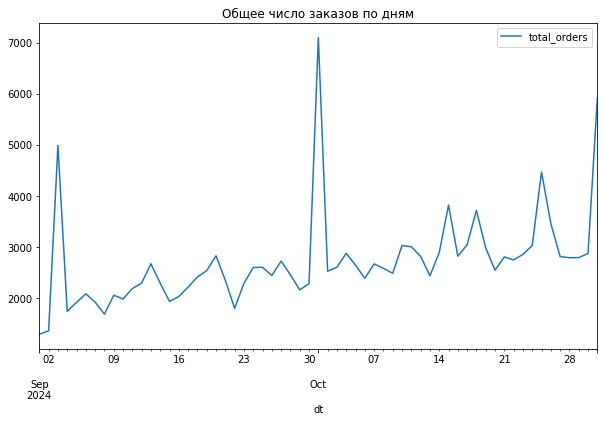

In [48]:
days.plot.line(x = 'dt',
               y = 'total_orders',
               title = 'Общее число заказов по дням',
               figsize = (10, 6))

<AxesSubplot:title={'center':'Количество активных пользователей в день'}, xlabel='dt'>

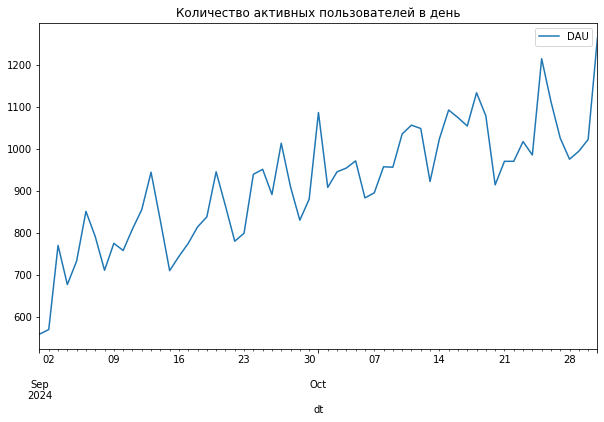

In [49]:
days.plot.line(x = 'dt',
               y = 'DAU',
               title = 'Количество активных пользователей в день',
               figsize = (10, 6))

<AxesSubplot:title={'center':'Среднее число заказов на одного пользователя'}, xlabel='dt'>

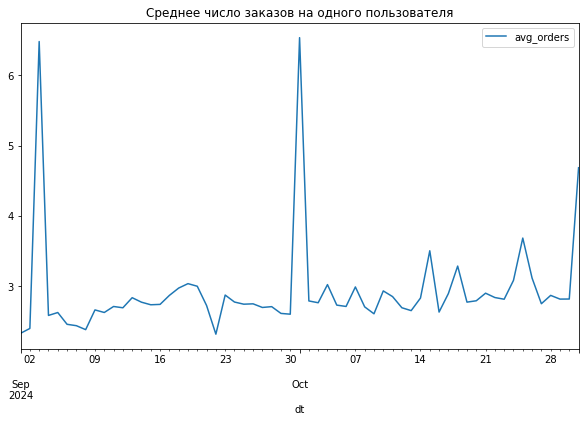

In [50]:
days.plot.line(x = 'dt',
               y = 'avg_orders',
               title = 'Среднее число заказов на одного пользователя',
               figsize = (10, 6))

<AxesSubplot:title={'center':'Средняя стоимость одного билета'}, xlabel='dt'>

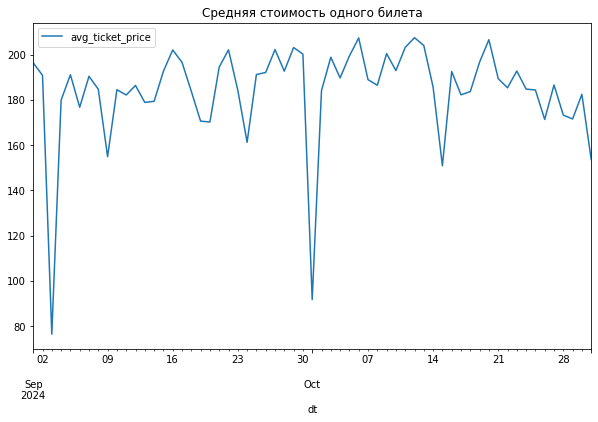

In [51]:
days.plot.line(x = 'dt',
               y = 'avg_ticket_price',
               title = 'Средняя стоимость одного билета',
               figsize = (10, 6))

Изучим недельную цикличность:

In [52]:
days['week'] = days['dt'].dt.day_of_week
weekly_activity = days.groupby('week').agg({'total_orders': 'mean',
                                            'DAU': 'mean',
                                            'avg_orders': 'mean',
                                            'avg_ticket_price': 'mean'}).round(2)
weekly_activity.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
weekly_activity

,total_orders,DAU,avg_orders,avg_ticket_price
Пн,2359.44,847.89,2.76,185.49
Вт,3430.56,926.78,3.68,156.08
Ср,2507.00,914.22,2.74,187.67
Чт,2986.22,955.56,3.05,183.60
Пт,3053.00,1013.75,2.98,186.10
Сб,2621.00,950.25,2.74,191.46
Вс,2124.67,814.89,2.59,198.13


Визуализируем основные данные, это `total_orders` и `DAU`:

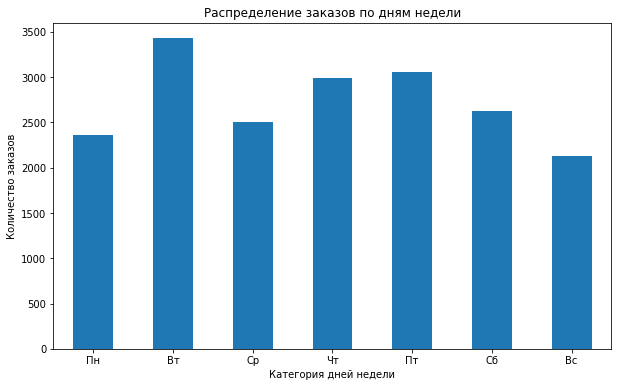

In [53]:
weekly_activity['total_orders'].plot(kind= 'bar',
                                     title= 'Распределение заказов по дням недели',
                                     ylabel= 'Количество заказов',
                                     xlabel= 'Категория дней недели',
                                     rot= 0,
                                     figsize= (10, 6))

plt.show()

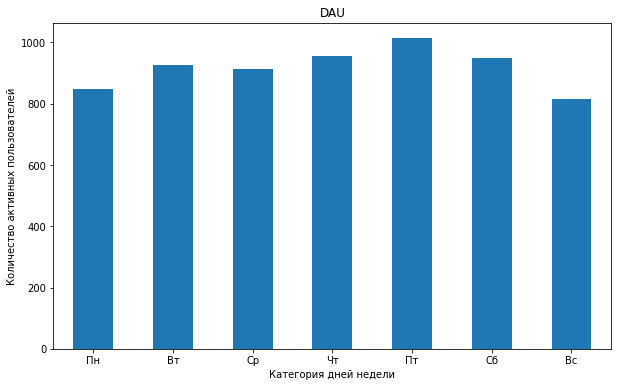

In [54]:
weekly_activity['DAU'].plot(kind= 'bar',
                            title= 'DAU',
                            ylabel= 'Количество активных пользователей',
                            xlabel= 'Категория дней недели',
                            rot= 0,
                            figsize= (10, 6))

plt.show()

**Вывод:**

**1. Динамика изменений по дням**

- **Общее число заказов** — демонстрирует значительный рост в конце октября, особенно заметны пики 3 сентября и 31 октября, что может быть связано с выходом новых мероприятий или началом сезона распродаж.
- **Количество активных пользователей (DAU)** — в целом повторяет динамику заказов, но с меньшей амплитудой. Максимальное значение DAU зафиксировано 31 октября (1264 пользователя).
- **Среднее число заказов на одного пользователя** — варьируется в диапазоне 2,3–2,9, с резким всплеском 3 сентября (6,48 заказа на пользователя), что указывает на аномальную активность небольшой группы пользователей в этот день.
- **Средняя стоимость одного билета** — колеблется в пределах 150–200 рублей, с заметным снижением 3 сентября (до 76,5 руб.) и 31 октября (до 153,7 руб.), что может объясняться распродажами или акциями.

**2. Недельная цикличность**

Анализ активности по дням недели выявил следующие закономерности:

**1. Количество заказов (total_orders)**
- **Пик активности** приходится на **вторник** (3 431 заказ) и **пятницу** (3 053 заказа).
- **Спад активности** наблюдается в **воскресенье** (2 125 заказов) и **понедельник** (2 359 заказов).
- Разница между максимальным (вторник) и минимальным (воскресенье) значениями составляет **61%**.

**2. Активные пользователи (DAU)**
- Наибольшее количество пользователей зафиксировано в **пятницу** (1 014 пользователей) и **четверг** (956 пользователей).
- Наименьшее — в **воскресенье** (815 пользователей) и **понедельник** (848 пользователей).

**3. Среднее число заказов на пользователя (avg_orders)**
- Максимальное значение — **во вторник (3.68)**, что указывает на высокую покупательскую активность этой группы пользователей.
- Минимальное — **в воскресенье (2.59)**.

**4. Средняя стоимость билета (avg_ticket_price)**
- Наиболее дорогие билеты продаются в **выходные дни**: суббота — 191 руб., воскресенье — 198 руб.
- Самая низкая цена — **во вторник (156 руб.)**, что коррелирует с максимальным количеством заказов в этот день (вероятно, акции или более доступные мероприятия).

**Ключевые выводы:**
- В начале недели (вторник) наблюдается **всплеск заказов** при низкой цене билета — возможно, пользователи активно планируют досуг на ближайшие выходные.
- В пятницу — **пик активности пользователей (DAU)** перед выходными.
- Выходные дни характеризуются **меньшим количеством заказов, но более высокой средней ценой билета** — пользователи выбирают более дорогие мероприятия (концерты, театры) либо покупают билеты в день мероприятия по более высокой цене.

### 3.3. Популярные события и партнёры

Посчитаем уникальное количество мероприятий и общее число заказов для каждого региона:

In [55]:
region_activity = df_autumn.groupby('region_name').agg({'event_id': 'nunique',
                                                        'order_id': 'count'})
region_activity.columns = ['events_total', 'orders_total']
region_activity['events_share'] = round(region_activity['events_total']/region_activity['events_total'].sum(), 2)
region_activity['orders_share'] = round(region_activity['orders_total']/region_activity['orders_total'].sum(), 2)
region_activity = region_activity.sort_values('events_total', ascending = False)
region_activity_top = region_activity.head(5)
region_activity_top

,events_total,orders_total,events_share,orders_share
region_name,,,,
Каменевский регион,3895,45951,0.25,0.28
Североярская область,2596,20341,0.16,0.12
Широковская область,799,8598,0.05,0.05
Светополянский округ,761,4724,0.05,0.03
Речиновская область,527,3512,0.03,0.02


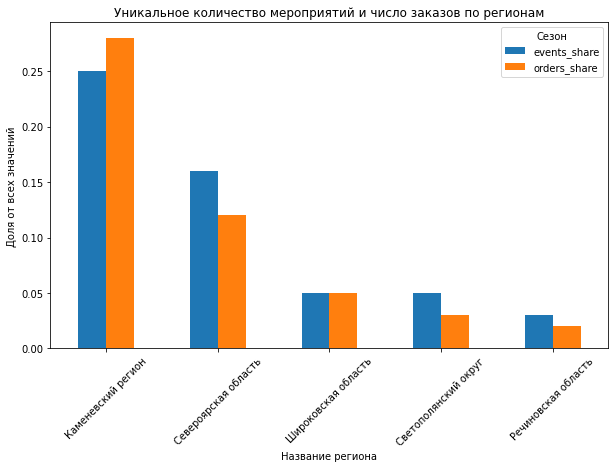

In [56]:
region_activity_top[['events_share', 'orders_share']].plot(kind= 'bar',
                                                           title= 'Уникальное количество мероприятий и число заказов по регионам',
                                                           ylabel= 'Доля от всех значений',
                                                           xlabel= 'Название региона',
                                                           rot= 45,
                                                           figsize= (10, 6))

plt.legend(title='Сезон')
plt.show()

Из данных видно что самое большое разнообразие мероприятий предлагается в следующих регионах:
1. **Каменевский регион** - 3895 мероприятий
2. **Североярская область** - 2596 мероприятий
3. **Широковская область** - 799 мероприятий

In [57]:
service_activity = df_autumn.groupby('service_name').agg({'event_id': 'nunique',
                                                          'order_id': 'count',
                                                          'revenue_rub': 'sum'})
service_activity.columns = ['events_total', 'orders_total', 'revenue_total']
service_activity['events_share'] = round(service_activity['events_total']/service_activity['events_total'].sum(), 2)
service_activity['orders_share'] = round(service_activity['orders_total']/service_activity['orders_total'].sum(), 2)
service_activity['revenue_share'] = round(service_activity['revenue_total']/service_activity['revenue_total'].sum(), 2)
service_activity = service_activity.sort_values('events_total', ascending = False)
service_activity_top = service_activity.head(5)
service_activity_top

,events_total,orders_total,revenue_total,events_share,orders_share,revenue_share
service_name,,,,,,
Лови билет!,3599,25400,1.010059e+07,0.21,0.15,0.13
Билеты без проблем,2830,31823,1.175508e+07,0.16,0.19,0.15
Билеты в руки,2458,25251,7.367462e+06,0.14,0.15,0.09
Облачко,1401,15342,1.042751e+07,0.08,0.09,0.13
Лучшие билеты,1390,12276,1.621018e+06,0.08,0.07,0.02


Из данных видно что самое большое разнообразие мероприятий предлагают следующие билетные партнеры:

1. **Лови билет!** - 3599 мероприятий
2. **Билеты без проблем** - 2830 мероприятий
3. **Билеты в руки** - 2458 мероприятий

Также выделим самых активных билетных партнеров по количеству заказов билетов и по выручке:

In [58]:
service_activity = service_activity.sort_values('orders_total', ascending = False)
service_activity.head()

,events_total,orders_total,revenue_total,events_share,orders_share,revenue_share
service_name,,,,,,
Билеты без проблем,2830,31823,1.175508e+07,0.16,0.19,0.15
Лови билет!,3599,25400,1.010059e+07,0.21,0.15,0.13
Билеты в руки,2458,25251,7.367462e+06,0.14,0.15,0.09
Мой билет,997,19165,1.058172e+07,0.06,0.12,0.13
Облачко,1401,15342,1.042751e+07,0.08,0.09,0.13


Видим что по количеству заказов лидируют те же билетные партнеры, но теперь они поменяли позиции:

1. **Билеты без проблем** - 31823 заказа
2. **Лови билет!** - 25400 заказов
3. **Билеты в руки** - 25251 заказ

In [59]:
service_activity = service_activity.sort_values('revenue_total', ascending = False)
service_activity.head()

,events_total,orders_total,revenue_total,events_share,orders_share,revenue_share
service_name,,,,,,
Билеты без проблем,2830,31823,1.175508e+07,0.16,0.19,0.15
Мой билет,997,19165,1.058172e+07,0.06,0.12,0.13
Облачко,1401,15342,1.042751e+07,0.08,0.09,0.13
Лови билет!,3599,25400,1.010059e+07,0.21,0.15,0.13
Весь в билетах,596,9290,9.121520e+06,0.03,0.06,0.11


По количеству выручки лидируют следующие билетные партнеры:

1. **Билеты без проблем** - 11 755 080 руб.
2. **Мой билет** - 10 581 720 руб.
3. **Облачко** - 10 427 510 руб.

Обобщенная визуализация:

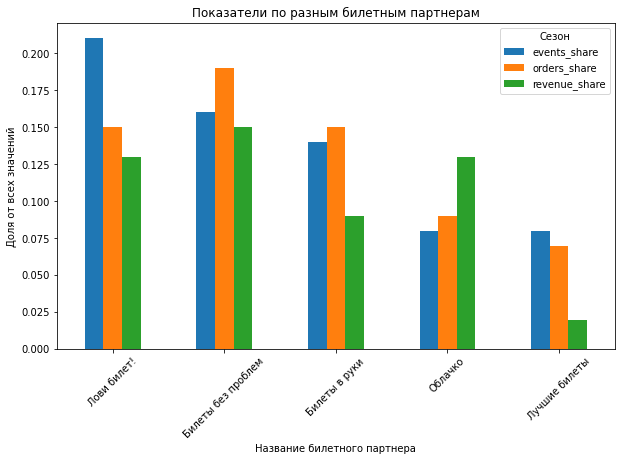

In [60]:
service_activity_top[['events_share', 'orders_share', 'revenue_share']].plot(kind= 'bar',
                                                                             title= 'Показатели по разным билетным партнерам',
                                                                             ylabel= 'Доля от всех значений',
                                                                             xlabel= 'Название билетного партнера',
                                                                             rot= 45,
                                                                             figsize= (10, 6))

plt.legend(title='Сезон')
plt.show()

**Вывод:**

**Анализ распределения мероприятий и заказов по регионам**

В ходе анализа были рассчитаны для каждого региона:
- количество уникальных мероприятий (`events_total`);
- общее количество заказов (`orders_total`);
- доля мероприятий региона в общем количестве мероприятий (`events_share`);
- доля заказов региона в общем количестве заказов (`orders_share`).

**Топ-5 регионов по разнообразию мероприятий:**

1. **Каменевский регион** - 3895 мероприятий
2. **Североярская область** - 2596 мероприятий
3. **Широковская область** - 799 мероприятий
4. **Светополянский округ** - 761 мероприятие
5. **Речиновская область** - 527 мероприятий

**Выводы по регионам:**
- **Явный лидер** — **Каменевский регион**, который концентрирует 25% всех мероприятий и 28% всех заказов.
- Второй по разнообразию — **Североярская область** (16% мероприятий, 12% заказов). Остальные регионы имеют долю мероприятий не более 5%.
- Наблюдается **неравномерное распределение**: топ-2 региона суммарно дают 41% мероприятий и 40% заказов, что свидетельствует о высокой концентрации активности в ограниченном числе регионов.
- Доля заказов в ряде регионов не соответствует доле мероприятий (например, в Североярской области мероприятий 16%, а заказов только 12%), что может указывать на разную востребованность событий или разный средний чек.

**Анализ активности билетных партнёров**

Для каждого партнёра рассчитаны:
- количество уникальных мероприятий (`events_total`);
- количество обработанных заказов (`orders_total`);
- суммарная выручка (`revenue_total`);
- доли в общем объеме.

**Топ-5 партнёров по разнообразию мероприятий:**

1. **Лови билет!** - 3599 мероприятий
2. **Билеты без проблем** - 2830 мероприятий
3. **Билеты в руки** - 2458 мероприятий
4. **Облачко** - 1401 мероприятие
5. **Лучшие билеты** - 1390 мероприятий

**Топ-5 партнёров по количеству заказов:**

1. **Билеты без проблем** - 31823 заказа
2. **Лови билет!** - 25400 заказов
3. **Билеты в руки** - 25251 заказ
4. **Мой билет** - 19165 заказов
5. **Облачко** - 15342 заказа

**Топ-5 партнёров по выручке:**

1. **Билеты без проблем** - 11 755 080 руб.
2. **Мой билет** - 10 581 720 руб.
3. **Облачко** - 10 427 510 руб.
4. **Лови билет!** - 10 100 590 руб.
5. **Весь в билетах** - 9 121 520 руб.

**Выводы по партнёрам:**
- **Явные лидеры по разнообразию мероприятий** — «Лови билет!» (21%), «Билеты без проблем» (16%), «Билеты в руки» (14%).
- **По количеству заказов** лидирует «Билеты без проблем» (19%), что свидетельствует о высокой популярности этих партнёров у пользователей.
- **По выручке** также лидирует «Билеты без проблем» (15%), но заметно, что «Мой билет» и «Облачко» при меньшем количестве заказов (12% и 9% соответственно) обеспечивают высокую выручку (по 13%), что говорит о более дорогих билетах у этих партнёров.
- Концентрация в сегменте партнёров также высока: топ-3 партнёра по мероприятиям дают 51% всего разнообразия, топ-3 по заказам — 49%, топ-3 по выручке — 41%.

**Общее заключение**

Как по регионам, так и по партнёрам наблюдается **высокая концентрация** — небольшое число лидеров формирует основную долю мероприятий, заказов и выручки. Это говорит о том, что для повышения устойчивости бизнеса стоит развивать сотрудничество с партнёрами из второго эшелона и стимулировать активность в регионах с большим количеством мероприятий, но низкой долей заказов (например, Североярская область).

## Шаг 4. Статистический анализ данных

Сначала сформулируем гипотезы для двух условий:

1. **Среднее количество заказов**:

**Н0** - Среднее количество заказов на одного пользователя мобильного приложения не отличается от среднего пользователей стационарных устройств, т.е. группа А = группе В

**Н1** - Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств, т.е. группа А > группы В

2. **Среднее время между заказами**:

**Н0** - Среднее время между заказами пользователей мобильных приложений не отличается от среднего пользователей стационарных устройств, т.е. группа А = группе В

**Н1** - Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств, т.е. группа А > группы В

**Выделим целевые метрики:**

Для первой гипотезы целевой метрикой будет являться **среднее количество заказов.**

Для второго гипотезы целевой метрикой будет являться **среднее время между заказами**

т.к. мы ничего не меняем а сравниваем две уже существующие категории пользователей, то барьерные метрики не нужны. Для статистического теста достаточно сфокусироваться на целевых метриках и корректно их рассчитать.

**Введем статистические параметры:**

1. Уровень значимости (α) - 0.05

Проверим есть ли пользователи, которые делали заказы с двух устройств, чтобы в дальнейшем исключить их из выборки:

In [61]:
both_devices = df_autumn.groupby('user_id')['device_type_canonical'].nunique().reset_index()
exclude = both_devices[both_devices['device_type_canonical'] > 1]['user_id'].tolist()
print(f"Найдено пользователей с обоими типами устройств: {len(exclude)}")

Найдено пользователей с обоими типами устройств: 3216


Теперь исключим этих пользователей из выборки:

In [62]:
df_autumn = df_autumn[~df_autumn['user_id'].isin(exclude)]

Рассчитаем целевые метрики:

Рассчитаем количество заказов:

In [63]:
user_orders = df_autumn.groupby(['user_id', 'device_type_canonical'])['order_id'].count().reset_index()
user_orders.columns = ['user_id', 'device_type', 'orders_count']
#Выделим мобильные и десктопные заказы для дальнейшего теста:
mobile_orders = user_orders[user_orders['device_type'] == 'mobile']['orders_count']
desktop_orders = user_orders[user_orders['device_type'] == 'desktop']['orders_count']

Рассчитаем среднее время между заказами:

In [64]:
#Удалим данные с пустыми значениями:
autumn_intervals = df_autumn[df_autumn['days_since_prev'].notna()]
#Выделим мобильные и десктопные заказы для дальнейшего теста:
mobile_intervals = autumn_intervals[autumn_intervals['device_type_canonical'] == 'mobile']['days_since_prev']
desktop_intervals = autumn_intervals[autumn_intervals['device_type_canonical'] == 'desktop']['days_since_prev']

Проведем тест Шапиро-Уилка для выбора статистического теста:

Для количества заказов:

In [65]:
mobile_sample = mobile_orders.sample(min(5000, len(mobile_orders)), random_state=42)
desktop_sample = desktop_orders.sample(min(5000, len(desktop_orders)), random_state=42)

shapiro_mobile = shapiro(mobile_sample)
shapiro_desktop = shapiro(desktop_sample)

print(f"Mobile (заказы): p-value = {shapiro_mobile.pvalue:.4f}")
print(f"Desktop (заказы): p-value = {shapiro_desktop.pvalue:.4f}")

Mobile (заказы): p-value = 0.0000
Desktop (заказы): p-value = 0.0000


Для среднего времени между заказами:

In [66]:
mobile_intervals_sample = mobile_intervals.sample(min(5000, len(mobile_intervals)), random_state=42)
desktop_intervals_sample = desktop_intervals.sample(min(5000, len(desktop_intervals)), random_state=42)

shapiro_mobile_int = shapiro(mobile_intervals_sample)
shapiro_desktop_int = shapiro(desktop_intervals_sample)

print(f"\nMobile (интервалы): p-value = {shapiro_mobile_int.pvalue:.4f}")
print(f"Desktop (интервалы): p-value = {shapiro_desktop_int.pvalue:.4f}")


Mobile (интервалы): p-value = 0.0000
Desktop (интервалы): p-value = 0.0000


Т.к. полученный в обоих случая p-value < 0.05, то можно сделать вывод что данные имеют ненормальное распределение. Таким образом необходимо воспользоваться тестом Манна-Уитни

Проведем тест для первой группы гипотез с количеством заказов:

In [67]:
alpha = 0.05
mw_test = mannwhitneyu(
    mobile_orders,
    desktop_orders,
    alternative='greater'
)
if mw_test.pvalue > alpha:
    print(f'pvalue={mw_test.pvalue} > {alpha}')
    print('Нулевая гипотеза находит подтверждение! Распределения метрики в группах A и B равны')
else:
    print(f'pvalue={mw_test.pvalue} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения! Распределения метрики в группах A и B различаются')

pvalue=5.3862737942764444e-39 < 0.05
Нулевая гипотеза не находит подтверждения! Распределения метрики в группах A и B различаются


Проведем тест для второй группы гипотез с временем между заказами:

In [68]:
alpha = 0.05
mw_test = mannwhitneyu(
    mobile_intervals,
    desktop_intervals,
    alternative='greater'
)
if mw_test.pvalue > alpha:
    print(f'pvalue={mw_test.pvalue} > {alpha}')
    print('Нулевая гипотеза находит подтверждение! Распределения метрики в группах A и B равны')
else:
    print(f'pvalue={mw_test.pvalue} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения! Распределения метрики в группах A и B различаются')

pvalue=6.694230527193331e-08 < 0.05
Нулевая гипотеза не находит подтверждения! Распределения метрики в группах A и B различаются


**Вывод:**

**1. Сравнение количества заказов на пользователя**

P-value 5.3862737942764444e-39 < 0.05, следовательно, нулевая гипотеза отвергается. **Различия между группами статистически значимы**. Пользователи мобильных устройств совершают в среднем больше заказов, чем пользователи десктопных устройств.

**2. Сравнение времени между заказами**


P-value 6.694230527193331e-08 < 0.05, следовательно, нулевая гипотеза отвергается. **Различия между группами статистически значимы**. Время между заказами у пользователей мобильных устройств в среднем больше, чем у пользователей десктопных устройств.


Статистический анализ подтверждает наличие значимых различий в поведении пользователей в зависимости от типа устройства:

1. **По количеству заказов:** мобильные пользователи демонстрируют более высокую активность (чаще совершают покупки), чем десктопные. Это может быть связано с большей доступностью мобильного приложения, push-уведомлениями и возможностью оформлять заказы в любое время и в любом месте.

2. **По времени между заказами:** мобильные пользователи имеют более длительные интервалы между покупками, что может показаться странным на фоне вывода о более высокой частоте заказов. Однако это может объясняться тем, что:
   - Мобильные пользователи могут совершать больше разовых покупок;
   - В выборке может быть больше новых пользователей, у которых еще не сформировалась регулярная покупательская привычка;
   - Десктопные пользователи могут быть более лояльной аудиторией с более стабильным и частым потреблением.

## Шаг 5. Общий вывод и рекомендации

**Информация о данных**

В ходе работы были проанализированы данные сервиса Яндекс.Афиша за период 2024 года, включающие:
- **заказы билетов** (290 611 записей) с информацией о пользователях, выручке, типе устройства и билетном операторе;
- **мероприятия** (информация о типе, организаторах, городе и площадке);
- **курс валют** для приведения выручки из тенге в рубли.

После предобработки (удаление выбросов по 99-му процентилю, устранение дубликатов, приведение валют) итоговый датафрейм составил 283 402 заказа. Анализ проводился с акцентом на сезонные изменения (лето vs осень 2024) и сравнение поведения пользователей мобильных и стационарных устройств.


**Основные результаты анализа**

**1. Сезонная динамика и популярность мероприятий**

- **Общее количество заказов** растет от июня к ноябрю: август — 43 894 заказа, октябрь — 97 722 заказа. Пик активности приходится на осенние месяцы, что указывает на сезонный рост спроса перед зимними праздниками.

- **Типы мероприятий:**
  - Летом лидируют **концерты** (43% заказов) и категория **«другое»** (27%).
  - Осенью доля **концертов** снижается до 37%, при этом растет доля **спорта** (с 2,5% до 11%) и **театров** (с 20% до 25%). Это может быть связано с началом спортивных сезонов и театральных премьер.

- **Средняя стоимость билета:**
  - Осенью заметно снизилась средняя цена на **концерты** (на 32%, с 410 до 280 руб.) и **театры** (на 17%, с 213 до 178 руб.).
  - Выросла цена на **выставки** (+3,5%) и **стендап** (+5,9%). Возможно, это связано с изменением пула мероприятий или ценовой политикой организаторов.

**2. Пользовательская активность**

- **Тип устройства:** независимо от сезона около **80% заказов** совершается с мобильных устройств. Это устойчивый тренд, подтверждающий важность мобильной версии сервиса.

- **Возрастные категории:**
  - Осенью выросла доля заказов на мероприятия без ограничений (0+) — с 18% до 23%.
  - Снизилась доля заказов на мероприятия 18+ (с 15% до 10%), что может говорить о смещении аудитории в сторону семейных и детских событий.

- **Динамика по дням:**
  
  Анализ активности по дням недели выявил следующие закономерности:

- Количество заказов (total_orders)**
  - **Пик активности** приходится на **вторник** (3 431 заказ) и **пятницу** (3 053 заказа).
  - **Спад активности** наблюдается в **воскресенье** (2 125 заказов) и **понедельник** (2 359 заказов).
  - Разница между максимальным (вторник) и минимальным (воскресенье) значениями составляет **61%**.

- Активные пользователи (DAU)**
  - Наибольшее количество пользователей зафиксировано в **пятницу** (1 014 пользователей) и **четверг** (956 пользователей).
  - Наименьшее — в **воскресенье** (815 пользователей) и **понедельник** (848 пользователей).

- Среднее число заказов на пользователя (avg_orders)**
  - Максимальное значение — **во вторник (3.68)**, что указывает на высокую покупательскую активность этой группы пользователей.
  - Минимальное — **в воскресенье (2.59)**.

- Средняя стоимость билета (avg_ticket_price)**
  - Наиболее дорогие билеты продаются в **выходные дни**: суббота — 191 руб., воскресенье — 198 руб.
  - Самая низкая цена — **во вторник (156 руб.)**, что коррелирует с максимальным количеством заказов в этот день (вероятно, акции или более доступные мероприятия).

**3. Регионы и партнеры**

- **Регионы-лидеры:**
  - **Каменевский регион** — 25% всех мероприятий и 28% заказов.
  - **Североярская область** — 16% мероприятий, 12% заказов (доля заказов ниже доли мероприятий, что может указывать на более низкий спрос).

- **Билетные партнеры:**
  - **По разнообразию мероприятий:** «Лови билет!» (21%), «Билеты без проблем» (16%), «Билеты в руки» (14%).
  - **По выручке:** «Билеты без проблем» (11,8 млн руб.), «Мой билет» (10,6 млн руб.), «Облачко» (10,4 млн руб.).
  - Обращает на себя внимание партнер «Мой билет»: при 6% мероприятий и 12% заказов он входит в топ-3 по выручке, что говорит о высоком среднем чеке.


**Результаты проверки гипотез**

Для сравнения мобильных и десктопных пользователей были проверены две гипотезы:

| Гипотеза | Результат | p-value | Вывод |
|----------|-----------|---------|-------|
| Среднее количество заказов у мобильных пользователей выше | **Подтверждена** | 5,39×10⁻³⁹ | Мобильные пользователи совершают заказы значимо чаще |
| Среднее время между заказами у мобильных пользователей выше | **Подтверждена** | 6,69×10⁻⁸ | Мобильные пользователи имеют более длительные интервалы между покупками |

**Интерпретация:**
- Мобильные пользователи активнее в плане частоты покупок, но при этом совершают их с большими временными разрывами.
- Возможное объяснение: мобильная аудитория более «широкая» и включает много разовых покупателей, тогда как десктопные пользователи могут быть более лояльной и регулярной аудиторией.


**Рекомендации**

1. **Усилить работу с мобильным каналом**
   - Учитывая, что 80% заказов приходится на мобильные устройства, стоит инвестировать в улучшение мобильного приложения и веб-версии: оптимизация скорости, персонализированные push-уведомления, упрощение процесса покупки.


2. **Сделать акцент на растущих категориях**
   - Осенью растет спрос на **спорт** и **театры**. Рекомендуется расширить предложение в этих категориях, а также запустить тематические акции (например, «Спортивный октябрь» или «Театральная осень»).


3. **Проанализировать партнеров с высоким средним чеком**
   - Партнеры «Мой билет» и «Облачко» показывают высокую выручку при относительно небольшом количестве заказов. Стоит изучить их ассортимент и рассмотреть возможность расширения сотрудничества.


4. **Стимулировать активность в регионах с отставанием заказов**
   - В Североярской области доля заказов ниже доли мероприятий. Возможные меры: таргетированная реклама, локальные акции, анализ причин низкого спроса.


5. **Работа с возрастными категориями**
   - Рост интереса к мероприятиям 0+ осенью говорит о востребованности семейного досуга. Стоит усилить продвижение таких событий в преддверии новогодних праздников.


6. **Использовать данные о недельной цикличности**
   - В выходные пользователи тратят больше на один билет. Можно тестировать премиальные предложения на выходные дни, а в будни — акции для повышения конверсии.